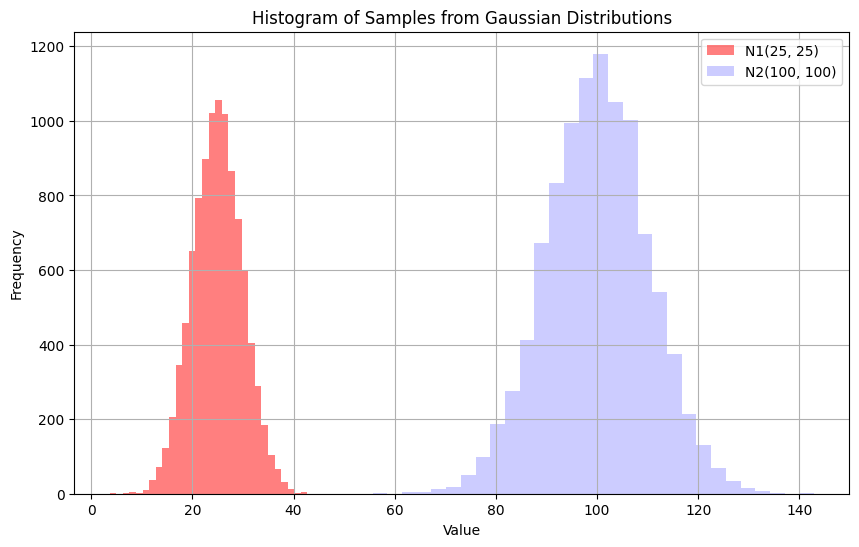

In [1]:
import numpy as np
import matplotlib.pyplot as plt

num_samples = 10000

# parameters for N1(25,25)
mean1 = 25
std1 = 5

# parameters for N2(100,100)
mean2 = 100
std2 = 10

# sample 10000 points from each distribution
samples1 = np.random.normal(mean1, std1, num_samples)
samples2 = np.random.normal(mean2, std2, num_samples)

# plotting
plt.figure(figsize=(10, 6))

# plot histogram for samples from N1
plt.hist(samples1, bins=30, alpha=0.5, color='red', label='N1(25, 25)')

# plot histogram for samples from N2
plt.hist(samples2, bins=30, alpha=0.2, color='blue', label='N2(100, 100)')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Samples from Gaussian Distributions')
plt.legend()
plt.grid(True)
plt.show()


In [2]:
# sort both sets of samples
sorted_indices1 = np.argsort(samples1)
sorted_indices2 = np.argsort(samples2)

# sort the samples using the obtained indices
sorted_samples1 = samples1[sorted_indices1.reshape(-1)]
sorted_samples2 = samples2[sorted_indices2.reshape(-1)]

In [3]:
# calculate the Wasserstein distance
distance = sorted_samples1 - sorted_samples2
wasserstein = (1/num_samples)*np.sum(distance**2)
print(wasserstein)

5661.3541662463695


verify the result, we calculate the closed form solution using the formula given in the exercise sheet.
Replace the parameters withe the values, we get:
$\|25-100\|_2^2 + trace (25+100-2*(10*25*20)^\frac{1}{2})$
$ = 75^2 + 125-2*50$
$ = 5625 + 25$
$ = 5650$

which is very close to our sample's wasserstein distance.

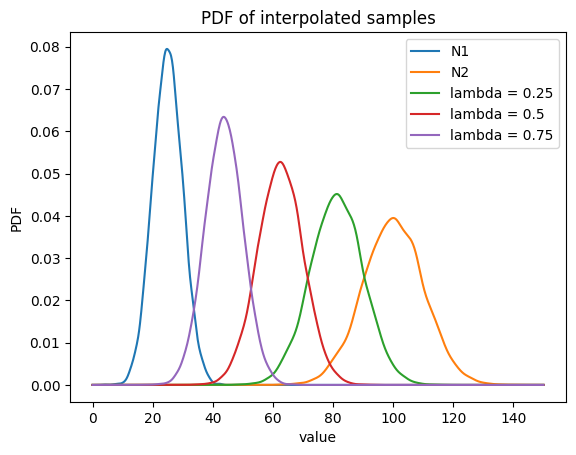

In [4]:
from scipy.stats import gaussian_kde

# generate samples by interpolating between the two distributions using the matching
sample_lambda_one = 0.25 * sorted_samples1 + 0.75 * sorted_samples2
sample_lambda_two = 0.5 * sorted_samples1 + 0.5 * sorted_samples2
sample_lambda_three = 0.75 * sorted_samples1 + 0.25 * sorted_samples2

kde_N1 = gaussian_kde(sorted_samples1)
kde_N2 = gaussian_kde(sorted_samples2)

# using gaussian kernels to estimate the pdf and plot
kde_one = gaussian_kde(sample_lambda_one)
kde_two = gaussian_kde(sample_lambda_two)
kde_three = gaussian_kde(sample_lambda_three)

# evaluate the KDE on a grid of points
x_grid = np.linspace(0, 150, 1000)
pdf_estimation_one = kde_one(x_grid)
pdf_estimation_two = kde_two(x_grid)
pdf_estimation_three = kde_three(x_grid)

pdf_N1 = kde_N1(x_grid)
pdf_N2 = kde_N2(x_grid)

# Plot the estimated PDF
plt.plot(x_grid, pdf_N1, label='N1')
plt.plot(x_grid, pdf_N2, label='N2')
plt.plot(x_grid, pdf_estimation_one, label='lambda = 0.25')
plt.plot(x_grid, pdf_estimation_two, label='lambda = 0.5')
plt.plot(x_grid, pdf_estimation_three, label='lambda = 0.75')
plt.xlabel('value')
plt.ylabel('PDF')
plt.title('PDF of interpolated samples')
plt.legend()
plt.show()

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


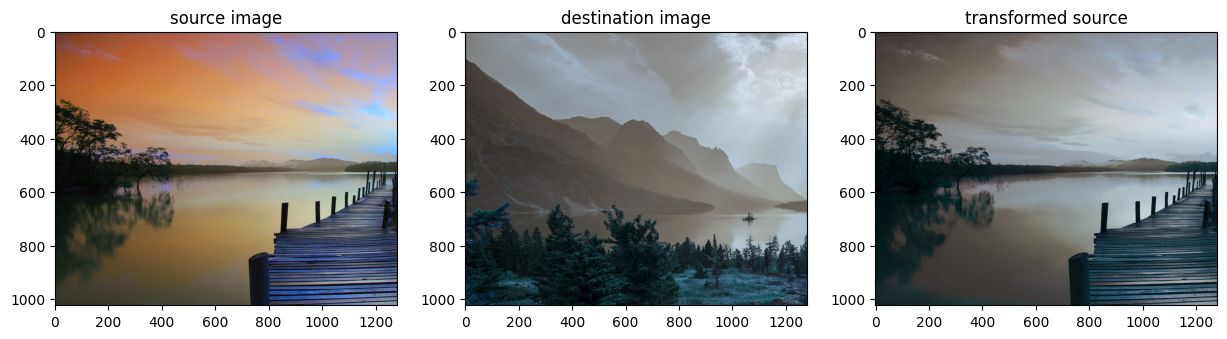

In [7]:
import cv2
# read the images
dst = cv2.imread('/content/drive/MyDrive/data/dst.png')
src = cv2.imread('/content/drive/MyDrive/data/src.png')

# convert the images to float32 and scale the values to the range [0, 1]
dst = dst.astype(np.float32) / 255.0
src = src.astype(np.float32) / 255.0

num_iterations = 100
num_vectors = 5

# create the two pixel multisets
dst_multiset = dst.reshape(-1,3)
src_multiset = src.copy().reshape(-1,3)

for i in range(num_iterations):
  update = np.zeros((src_multiset.shape[0],3))
  for j in range(num_vectors):
    # create a random normalized vector in 3D
    random_vector = np.random.randn(3).reshape(-1, 1)
    normalized_vector = random_vector / np.linalg.norm(random_vector)

    # project onto the normalized vector
    x = src_multiset @ normalized_vector
    y = dst_multiset @ normalized_vector

    # sort both projections
    sorted_x_indices = np.argsort(x.reshape(-1))
    sorted_y_indices = np.argsort(y.reshape(-1))

    # sort the projections using the obtained indices
    sorted_x = x[sorted_x_indices]
    sorted_y = y[sorted_y_indices]

    diff = sorted_y - sorted_x

    # create the inverse index array
    inverse_indices = np.empty_like(sorted_x_indices)
    inverse_indices[sorted_x_indices] = np.arange(len(sorted_x_indices))
    diff_inversed = diff[inverse_indices]
    update_to_add = diff_inversed @ normalized_vector.reshape((1,3))
    update += update_to_add

  # average the updates of the vectors
  update /= num_vectors
  # update the source image
  src_multiset += update

transformed_src = src_multiset.reshape((src.shape[0], src.shape[1], 3))

plt.figure(figsize=(15, 5))  # Adjust the width and height as needed

# display the source image
plt.subplot(1, 3, 1)
plt.imshow(src)
plt.title('source image')

# display the destination image
plt.subplot(1, 3, 2)
plt.imshow(dst)
plt.title('destination image')

# display the transformed src
plt.subplot(1, 3, 3)
plt.imshow(transformed_src)
plt.title('transformed source')

plt.show()





